# Rice Project detection
* THis is one of the more intresrting project's that I worked to machine learning.
* To this project I used from `Rice Classification` dataset.
* After that I userd from dropna to drop id because this feature is don't had efficiently to predict the data.
* At the end of my program you can observe the graph that has four kind of the data list's by the names' of total_loss_train, total_loss_valid,total_acc_train_plot,total_acc_valid_plot
these show for us, how much our data become fine.


In [1]:
import torch as tr
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt # It's used for draw the diagram and use to visualiztion of our data
import numpy as np
import pandas as pd

"""
Accuracy Formula---> acc = (TurePositive+TureNegative)/TurePositive+TruePositive+FlasePositve+FalseNegative
    
"""

'\nAccuracy Formula---> acc = (TurePositive+TureNegative)/TurePositive+TruePositive+FlasePositve+FalseNegative\n\n'

In [56]:
df = pd.read_csv(r'riceClassification.csv')
df.head(5)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [3]:
df.dropna(inplace = True)
df.drop(['id'], axis = 1,inplace = True)
df.shape

(18185, 11)

In [57]:
df.head(5)

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
device = 'cuda' if tr.cuda.is_available() else 'cpu'
device

'cpu'

In [6]:

p = df['Class']
p

0        1
1        1
2        1
3        1
4        1
        ..
18180    0
18181    0
18182    0
18183    0
18184    0
Name: Class, Length: 18185, dtype: int64

In [7]:
p = df['Class']
print(p.unique(),p[-10:])

[1 0] 18175    0
18176    0
18177    0
18178    0
18179    0
18180    0
18181    0
18182    0
18183    0
18184    0
Name: Class, dtype: int64


In [8]:
print(p.value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [9]:
original_data = df.copy()
original_data

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [10]:
original_data.shape

(18185, 11)

In [11]:
for column in df.columns:
    df[column] = df[column]/df[column].abs().max()
# original_data >= df # Now we can say that the value of our ancient data are largen than df data
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [12]:
x = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:,-1])
type(x),type(y)


(numpy.ndarray, numpy.ndarray)

In [13]:
x[:5],y[:5]

(array([[0.44436827, 0.50340371, 0.77543522, 0.7446585 , 0.42487282,
         0.66660953, 0.74166052, 0.5370287 , 0.844997  , 0.36831616],
        [0.28129285, 0.40768133, 0.62265269, 0.75048874, 0.27389172,
         0.53037048, 0.80423032, 0.40966075, 0.91921498, 0.37147093],
        [0.29853085, 0.41642141, 0.63044229, 0.75634138, 0.28452035,
         0.54637977, 0.85627819, 0.41299402, 0.95986205, 0.37474651],
        [0.30097943, 0.42046299, 0.62904915, 0.76402442, 0.28679142,
         0.54861592, 0.88377241, 0.41426243, 0.96181789, 0.37922161],
        [0.36170421, 0.46462594, 0.68290127, 0.77503309, 0.34538517,
         0.6014185 , 0.86780778, 0.45295382, 0.96683604, 0.38600721]]),
 array([1., 1., 1., 1., 1.]))

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3)
x_test,x_val,y_test,y_val = train_test_split(x_test,y_test,test_size = 0.4)

print(x_train.shape,x_test.shape,x_val.shape)
print("Total datas in  our dataset --> ",len(x_train)+len(x_test)+len(x_val))

(12729, 10) (3273, 10) (2183, 10)
Total datas in  our dataset -->  18185


In [15]:
class dataset(Dataset):
    def __init__(self,X,Y):
        self.X = tr.tensor(X, dtype = tr.float32).to(device)
        self.Y = tr.tensor(Y, dtype = tr.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
       return self.X[index],self.Y[index]
   
   
dataset(x_train,y_train)   

In [16]:
train_data = dataset(x_train,y_train)
validation_data = dataset(x_val,y_val)
test_data = dataset(x_test,y_test)
print(f'Train the data ----->> {train_data}')
print(f'validation the data ----->> {validation_data}')
print(f'Testing the data ----->> {test_data}')

Train the data ----->> <__main__.dataset object at 0x000002B9522A8410>
validation the data ----->> <__main__.dataset object at 0x000002B9522A8690>
Testing the data ----->> <__main__.dataset object at 0x000002B9521DA8B0>


In [17]:
train_loader = DataLoader(train_data,batch_size = 32, shuffle = True)
valid_loader = DataLoader(validation_data,batch_size = 32,shuffle = True)
test_loader = DataLoader(test_data,batch_size = 32,shuffle = True)
print(f'Train the data ----->> {train_data}')
print(f'validation the data ----->> {validation_data}')
print(f'Testing the data ----->> {test_data}')

Train the data ----->> <__main__.dataset object at 0x000002B9522A8410>
validation the data ----->> <__main__.dataset object at 0x000002B9522A8690>
Testing the data ----->> <__main__.dataset object at 0x000002B9521DA8B0>


In [18]:
for x,y in train_loader:
    print(x)
    print('====== '*12)
    print(y)
    break

tensor([[0.6467, 0.7378, 0.7645, 0.9147, 0.6141, 0.8042, 0.8693, 0.6365, 0.8755,
         0.5475],
        [0.9515, 0.9367, 0.8854, 0.9359, 0.9135, 0.9755, 0.8900, 0.8227, 0.7711,
         0.6002],
        [0.6050, 0.8297, 0.6427, 0.9693, 0.5799, 0.7778, 0.6725, 0.6794, 0.7188,
         0.7325],
        [0.5588, 0.7991, 0.6125, 0.9707, 0.5288, 0.7475, 0.5580, 0.6413, 0.7451,
         0.7402],
        [0.4424, 0.7507, 0.5104, 0.9846, 0.4187, 0.6651, 0.9053, 0.5872, 0.7036,
         0.8345],
        [0.8171, 0.8268, 0.8599, 0.9138, 0.7783, 0.9040, 0.8656, 0.7270, 0.8478,
         0.5455],
        [0.8209, 0.8264, 0.8727, 0.9098, 0.7843, 0.9060, 0.8031, 0.7230, 0.8612,
         0.5372],
        [0.5868, 0.8111, 0.6357, 0.9677, 0.5609, 0.7660, 0.8781, 0.6670, 0.7233,
         0.7239],
        [0.5898, 0.8372, 0.6197, 0.9751, 0.5612, 0.7680, 0.7598, 0.6720, 0.7162,
         0.7664],
        [0.5795, 0.8152, 0.6202, 0.9717, 0.5482, 0.7613, 0.7546, 0.6575, 0.7352,
         0.7457],
        [0

In [19]:
# It's a class I maked for make my hidden layer.
hidden_number = 7
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel,self).__init__()
        self.input_layer1 = nn.Linear(x.shape[1],hidden_number)
        self.input_layer2 = nn.Linear(7,15)
        self.Linears = nn.Linear(15,1)
        self.sigmoid = nn.Sigmoid()
    def forward(self,X):
        X = self.input_layer1(X)
        X = self.input_layer2(X)
        X = self.Linears(X)
        X = self.sigmoid(X)
        return X

    

model = MyModel()
model

MyModel(
  (input_layer1): Linear(in_features=10, out_features=7, bias=True)
  (input_layer2): Linear(in_features=7, out_features=15, bias=True)
  (Linears): Linear(in_features=15, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [20]:
summary(model,(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 7]              77
            Linear-2                   [-1, 15]             120
            Linear-3                    [-1, 1]              16
           Sigmoid-4                    [-1, 1]               0
Total params: 213
Trainable params: 213
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [21]:
criterition = nn.BCELoss()

criterition

BCELoss()

In [22]:
optimizer = tr.optim.Adam(model.parameters(),lr = 0.001)

In [23]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

# Trianing the data

In [24]:
print(len(set(train_data)))
print(len(set(validation_data)))

12729
2183


In [25]:
total_loss_train_plot= []
total_loss_valid_plot = []
total_acc_train_plot = []
total_acc_valid_plot= []

epochs = 8
for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_valid = 0
    
    # Now we use from for loop.
    for  inputs,labels in train_loader:
        inputs,labels = inputs.to(device),labels.to(device)
        prediction = model(inputs).squeeze(1)
        batch_loss = criterition(prediction,labels)
        total_loss_train += batch_loss.item()
        acc = ((prediction).round() == labels).sum().item()
        total_acc_train += acc
        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    model.eval()  
    with tr.no_grad():
        for data in valid_loader:
            input, label = data
            prediction = model(input).squeeze(1)
            batch_loss = criterition(prediction,label)
            total_loss_valid += batch_loss.item()
            acc = ((prediction).round() == label).sum().item()
            total_acc_val += acc 
            

    total_loss_train_plot.append(round(total_loss_train/1000,4))        
    total_loss_valid_plot.append(round(total_loss_valid/1000,4))
    
    total_acc_train_plot.append(round(total_acc_train/train_data.__len__() * 100,4)) 
    total_acc_valid_plot.append(round(total_acc_val/validation_data.__len__() * 100,4))
    """
    # What is Round?
    # Answer: Round is a number to a given precision in decimal digits
    """
   
   
    print(F'''Epoch: {epoch+1} Train Loss: {round(total_loss_train/1000,4)}, Train Accuracy {round(total_acc_train/train_data.__len__()*100,4)} || Validation Loss: {round(total_loss_valid/1000,4)}, Vlidation Accuracy: {round(total_acc_val/validation_data.__len__()*100,4)}''')
 
 

Epoch: 1 Train Loss: 0.1816, Train Accuracy 82.7873 || Validation Loss: 0.0073, Vlidation Accuracy: 98.809
Epoch: 2 Train Loss: 0.0276, Train Accuracy 98.3895 || Validation Loss: 0.003, Vlidation Accuracy: 98.9464
Epoch: 3 Train Loss: 0.0192, Train Accuracy 98.5073 || Validation Loss: 0.0022, Vlidation Accuracy: 99.1296
Epoch: 4 Train Loss: 0.0176, Train Accuracy 98.5859 || Validation Loss: 0.0021, Vlidation Accuracy: 98.9464
Epoch: 5 Train Loss: 0.0175, Train Accuracy 98.5623 || Validation Loss: 0.002, Vlidation Accuracy: 99.2213
Epoch: 6 Train Loss: 0.0174, Train Accuracy 98.5073 || Validation Loss: 0.0019, Vlidation Accuracy: 99.1754
Epoch: 7 Train Loss: 0.0173, Train Accuracy 98.5938 || Validation Loss: 0.0019, Vlidation Accuracy: 99.0838
Epoch: 8 Train Loss: 0.0172, Train Accuracy 98.4602 || Validation Loss: 0.0022, Vlidation Accuracy: 98.9464


In [26]:
with tr.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_data:
        inputs , labels = data
        prediction = model(inputs).squeeze()
        batch_loss_test = criterition(prediction,labels).item()
        acc= ((prediction).round() == labels).sum().item()
        total_acc_test += acc
    print(f'Train Accuracy {round(total_acc_train/train_data.__len__()*100,4)}')
    print(f"Total accuracy test:{round(total_acc_test/test_data.__len__()*100,4)}")

Train Accuracy 98.4602
Total accuracy test:98.5946


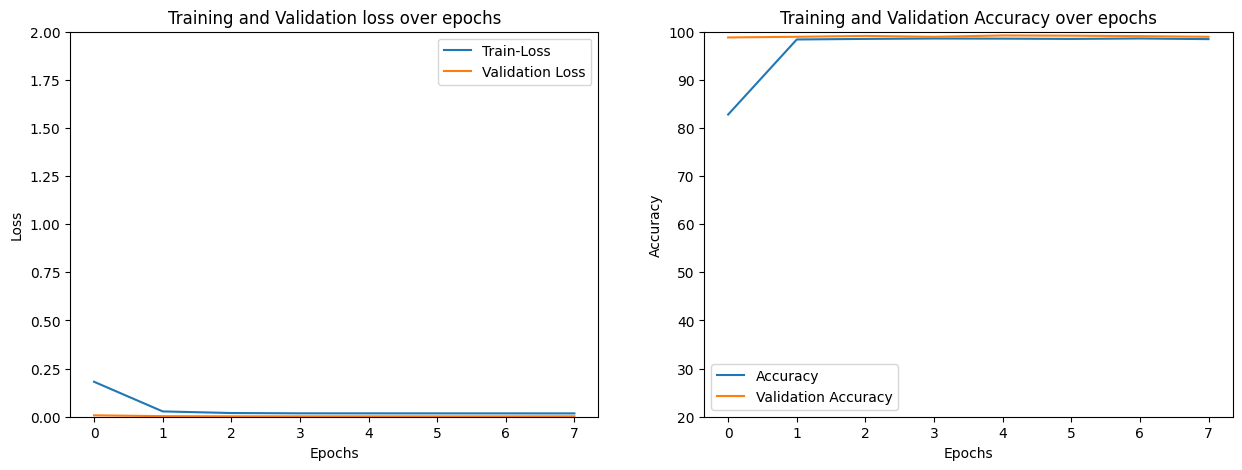

In [27]:
# Now we want to visualization our data.
fig, axs = plt.subplots(nrows=1,ncols=2,figsize =(15,5))
axs[0].plot(total_loss_train_plot,label = "Train-Loss")
axs[0].plot(total_loss_valid_plot,label = 'Validation Loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,2])
axs[0].legend()

# showing the accuracy

axs[1].plot(total_acc_train_plot,label = "Accuracy")
axs[1].plot(total_acc_valid_plot,label = 'Validation Accuracy')
axs[1].set_title("Training and Validation Accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([20,100])
axs[1].legend()



plt.show()

In [53]:
area = 1 /original_data["Area"].abs().max()
majorAxisLength = 2/original_data["MajorAxisLength"].abs().max()
minorAxislength = 89/original_data["MinorAxisLength"].abs().max()
Eccentricity = 1/original_data["Eccentricity"].abs().max()
convex = 17/original_data["ConvexArea"].abs().max()
EquivDiameter = 1/original_data["EquivDiameter"].abs().max()
Extent = 3000/original_data["Extent"].abs().max()
Perimeter = 100/original_data["Perimeter"].abs().max()
Roundness = 1000/original_data["Roundness"].abs().max()
AspectRation = 211/original_data['AspectRation'].abs().max()
my_prediction = model(tr.tensor([area,majorAxisLength,minorAxislength,Eccentricity,convex,EquivDiameter,Extent,Perimeter,Roundness,AspectRation],dtype = tr.float32).to(device))

if my_prediction > 0.5:
    print("This is a rice_ ")
elif my_prediction == 0.5:
    print("May be it is a rice_ ")
else:
    print("This is not a rice")


This is not a rice
